In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
df_exploded = df.explode('job_skills')
skills_count = df_exploded.groupby(['job_skills','job_title_short']).size()
type(skills_count)


pandas.Series

In [9]:
df_skills_count = skills_count.reset_index(name = 'skill_count')
df_skills_count = df_skills_count.sort_values(by = 'skill_count', ascending = False)

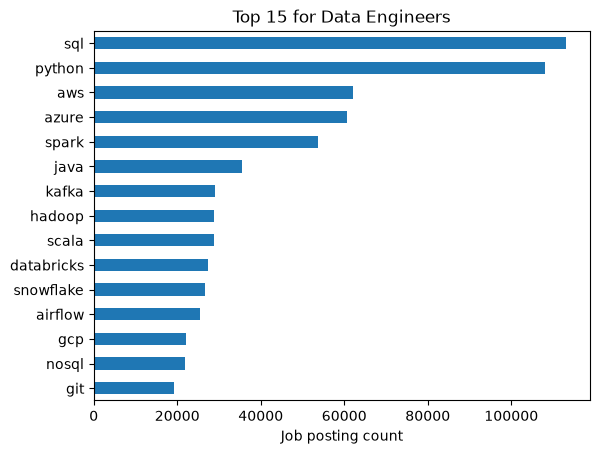

In [17]:
job_title = 'Data Engineer'
top_skills = 15
df_skill_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)
df_skill_final.plot(kind='barh', x = 'job_skills', y = 'skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} for {job_title}s')
plt.xlabel('Job posting count')
plt.ylabel('')
plt.legend().set_visible(False)